# 06c — G=28 reproduction (faithful semantic-category vocabulary)

Reproduces the paper's headline barycenter result on the **G=28 semantic-category** vocabulary
(27 named cooking-action categories + 1 background symbol), the representation the thesis
actually used (`archive-notebooks/demo_rtwe_barycenter_averaging.ipynb`) — *not* the K-space
G=77 prototypes of 06b.

Pipeline (all faithful to the thesis):
- **vocabulary**: `filtered_raw_embedding_labels` → `add_pyramid_labels` → `mapping_cluster_category` →
  `update_segmentation(majority_voting_inner)` → integer codes (background = 0). See `vocab.add_category_columns`.
- **ground cost `D_G`**: 28×28 *temporal-occurrence* Wasserstein-1 between categories' normalized
  occurrence-time distributions (`vocab.recompute_category_temporal_D_G`), then the thesis
  `compute_distance_matrix` transform (+0.3 offset, /max, background row/col = max).
- **barycenter**: faithful mean-rTWE-DBA (ν=1e-4, λ=0.1) + p_match feature, plus mode / D_G-Fréchet
  variants, compared against the frequency baselines on the **same harness** (`evaluate_baselines`).

**Question**: does the **histogram** (and the barycenter+p_match) reach ≈0.84 on RIL-vs-Control at G=28?
Reported honestly — no tuning to make alignment win.

In [1]:
%load_ext autoreload
%autoreload 2
import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
import smartflat
from joblib import load, dump
from smartflat.utils.utils_io import get_data_root
from smartflat.utils.utils import upsample_sequence
from smartflat.constants import incomplete_clinical_administrations
from smartflat.features.symbolization.utils import fix_clinical_diagnosis
from smartflat.features.symbolization.utils_dataset import get_experiments_dataframe
from smartflat.features.symbolic_barycenter import vocab
from smartflat.features.symbolic_barycenter import baselines as B
from smartflat.features.symbolic_barycenter.baselines import make_patient_control_labels
from smartflat.features.symbolic_barycenter.visualization import plot_cohort_barycenters
from smartflat.engine.distances._rtwe import rtwe_pairwise_distance
plt.rcParams['figure.dpi'] = 110


2026-06-06 08:50:46.216419: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-06 08:50:46.232744: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780728646.250978 2724089 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780728646.256564 2724089 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780728646.272259 2724089 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# --- parameters (thesis G=28 settings) ---
ANN, RND, CFG = 'samperochon', 8, 'SymbolicSourceInferenceGoldConfig'
L = 64               # resample length (harness tractability; discrimination is L-insensitive)
NU, LMBDA = 1e-4, 0.1  # thesis hyperparameters for the G=28 result
OFFSET = 0.3         # compute_distance_matrix offset (thesis)
OUT = os.path.join(get_data_root(), 'outputs', 'symbolic_barycenter', 'g28')
os.makedirs(OUT, exist_ok=True)
print('output dir:', OUT)


output dir: /home/perochon/data-gold-final/outputs/symbolic_barycenter/g28


In [3]:
# --- build (or load cached) the G=28 category columns + raw temporal D_G on the FULL cohort ---
cache_df = os.path.join(OUT, 'g28_full_with_cat.pkl')
cache_D  = os.path.join(OUT, 'D_G_cat_temporal_raw.npy')
cache_code = os.path.join(OUT, 'category_codes.json')

if all(os.path.exists(p) for p in [cache_df, cache_D, cache_code]):
    dff = load(cache_df); D_raw = np.load(cache_D); code = json.load(open(cache_code))
    code_to_label = [None]*len(code)
    for k, v in code.items():
        code_to_label[v] = k
    print('loaded cached category df + raw temporal D_G')
else:
    dff = get_experiments_dataframe(experiment_config_name=CFG, annotator_id=ANN,
                                    round_number=RND, return_symbolization=True, return_data_only=True)
    dff, code, code_to_label = vocab.add_category_columns(dff, CFG, ANN, RND)
    D_raw = vocab.recompute_category_temporal_D_G(dff, config_name=CFG, annotator_id=ANN,
                                                  round_number=RND, overwrite=True)
    dump(dff, cache_df); np.save(cache_D, D_raw); json.dump(code, open(cache_code, 'w'))
    print('built + cached category df + raw temporal D_G')

# --- mapping gate (hard-stop on divergence from the established recipe) ---
uniq = np.unique(np.hstack(dff['cat_segm_embedding_labels'].values))
tot = sum(len(s) for s in dff['cat_segm_embedding_labels'])
bg  = sum(int((np.asarray(s) == '-1').sum()) for s in dff['cat_segm_embedding_labels'])
print(f'alphabet (incl background) = {len(uniq)} | named categories = {len(uniq)-1} | '
      f'token coverage = {100*(1-bg/tot):.1f}%')
assert len(uniq) == 28, f'expected a 28-symbol alphabet, got {len(uniq)}'
print('category codes:', {v: code_to_label[v] for v in range(len(code_to_label))})


loaded cached category df + raw temporal D_G
alphabet (incl background) = 28 | named categories = 27 | token coverage = 76.6%
category codes: {0: '-1', 1: 'break chocolate', 2: 'break eggs', 3: 'butter', 4: 'clean hands', 5: 'exogeneous', 6: 'fridge', 7: 'look kitchen', 8: 'look shelf', 9: 'look window', 10: 'manipulate oven', 11: 'merge butter chocolate', 12: 'merge flour/eggs/sugar', 13: 'merge flour/sugar', 14: 'merge white eggs', 15: 'open box ingredients', 16: 'open butter/chocolate', 17: 'plug mixer', 18: 'poor dough into pan', 19: 'poor flour/sugar', 20: 'prepare mixer', 21: 'recipe', 22: 'setting oven', 23: 'talking', 24: 'use balance', 25: 'use measuring cup', 26: 'use mixer', 27: 'use sink'}


In [4]:
# --- clinical filter -> analysis cohort (mirrors NB06 cell 5), then build X_cat ---
df = fix_clinical_diagnosis(dff.copy())
df = df[~df['participant_id'].isin(incomplete_clinical_administrations.keys())]
df.sort_values('task_number_int', ascending=True, inplace=True)
df = df[df['pathologie'].isin(['HEALTHY', 'RIL', 'TBI'])]
df.drop_duplicates(subset=['trigram'], keep='first', inplace=True)
df = df.reset_index(drop=True)

X_cat = np.vstack([upsample_sequence(np.asarray(s), L)
                   for s in df['int_cat_segm_embedding_labels']]).astype(int)
labels = df['pathologie'].values.astype(object)
assert X_cat.min() >= 0
print('cohort:', df.groupby('pathologie').size().to_dict())
print('X_cat:', X_cat.shape, '| distinct symbols occurring:', len(np.unique(X_cat)), '| max code:', X_cat.max())


cohort: {'HEALTHY': 24, 'RIL': 37, 'TBI': 59}
X_cat: (120, 64) | distinct symbols occurring: 28 | max code: 27


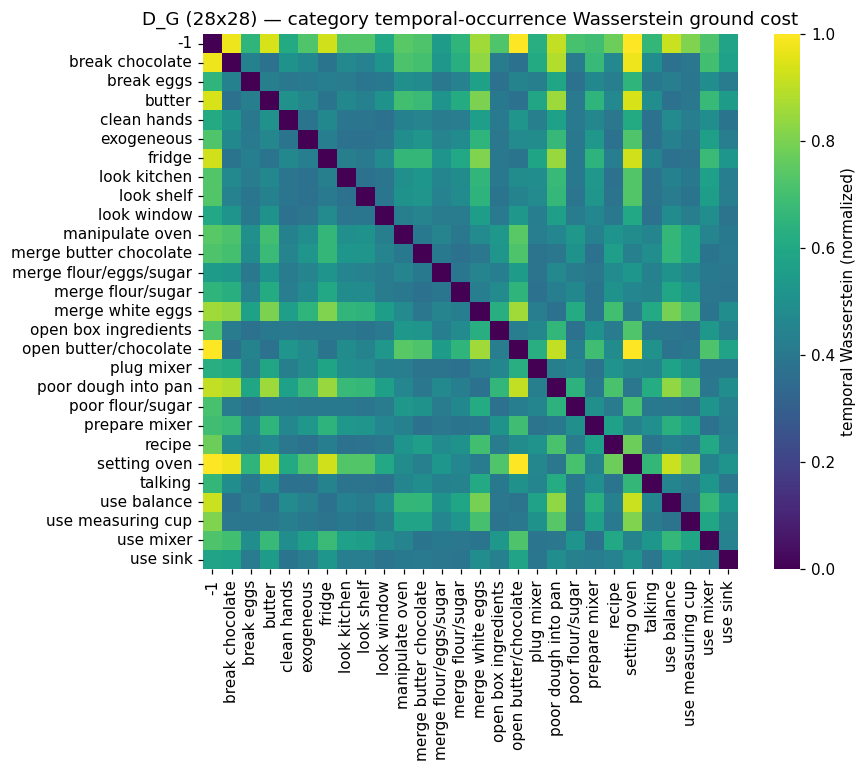

In [5]:
# --- ground cost D_G_cat (thesis transform) + heatmap ---
D_G_cat = vocab.compute_distance_matrix(D_raw, offset_value=OFFSET)  # 28x28, zero diag, bg row/col = max
np.save(os.path.join(OUT, 'D_G_cat.npy'), D_G_cat)
assert D_G_cat.shape[0] == 28 and np.allclose(D_G_cat, D_G_cat.T) and np.allclose(np.diag(D_G_cat), 0)

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(D_G_cat, cmap='viridis', xticklabels=code_to_label, yticklabels=code_to_label,
            ax=ax, square=True, cbar_kws={'label': 'temporal Wasserstein (normalized)'})
ax.set_title('D_G (28x28) — category temporal-occurrence Wasserstein ground cost')
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'g28_DGcat_heatmap.png'), dpi=130); plt.show()


## Baseline comparison on the G=28 representation

Same `evaluate_baselines` harness + native-distance design as 06b. Methods:
- **frequency**: `wasserstein` (histogram), `majority_voting`, `edit_median`, `k_medoid`.
- **proposed (TW-TWE + DBA)**: `tw_twe_thesis` (faithful mean-rTWE-DBA, fractional, + stock-TWE
  Match_normalized), `tw_twe_mean` (rounded mean + rTWE p_match), `tw_twe_mode` (mode-DBA + p_match),
  `tw_twe_dg` (D_G-Fréchet projection + p_match).
- **ablation**: `twe_ablation` (mode-DBA with an ordinal ground cost — isolates the Wasserstein cost).
- **embedding** (reduced budget): `dba_dtw`, `soft_dtw`.

In [6]:
# --- method registry on D_G_cat ---
fast = dict(B.default_baseline_methods(D_G_cat, nu=NU, lmbda=LMBDA))
slow = {k: fast.pop(k) for k in ['dba_dtw', 'soft_dtw'] if k in fast}
D_ord = B.ordinal_cost_matrix(D_G_cat.shape[0])

fast['tw_twe_thesis'] = {  # closest reconstruction of the thesis barycenter + scoring
    'build': lambda X, seed: B.barycenter_mean_rtwe_dba(X, D_G_cat, nu=NU, lmbda=LMBDA,
                                                        init='random', project='none', random_state=seed),
    'distance': lambda s, b: B.dist_neg_pmatch_stock(s, b, nu=NU, lmbda=LMBDA)}
fast['tw_twe_mean'] = {
    'build': lambda X, seed: B.barycenter_mean_rtwe_dba(X, D_G_cat, nu=NU, lmbda=LMBDA,
                                                        init='random', project='round', random_state=seed),
    'distance': lambda s, b: B.dist_neg_pmatch(s, b, D_G_cat, nu=NU, lmbda=LMBDA)}
fast['tw_twe_mode'] = {
    'build': lambda X, seed: B.barycenter_mode_dba(X, D_G_cat, nu=NU, lmbda=LMBDA),
    'distance': lambda s, b: B.dist_neg_pmatch(s, b, D_G_cat, nu=NU, lmbda=LMBDA)}
fast['tw_twe_dg'] = {
    'build': lambda X, seed: B.barycenter_mean_rtwe_dba(X, D_G_cat, nu=NU, lmbda=LMBDA,
                                                        init='random', project='dg', random_state=seed),
    'distance': lambda s, b: B.dist_neg_pmatch(s, b, D_G_cat, nu=NU, lmbda=LMBDA)}
fast['twe_ablation'] = {
    'build': lambda X, seed: B.barycenter_mode_dba(X, D_ord, nu=NU, lmbda=LMBDA),
    'distance': lambda s, b: B.dist_rtwe(s, b, D_ord, nu=NU, lmbda=LMBDA)}

# pairwise TW-TWE distance matrix for k_medoid
D_pw = rtwe_pairwise_distance(X_cat[:, None, :].astype(float), nu=NU, lmbda=LMBDA,
                              precomputed_distances=D_G_cat)
print('registered methods:', sorted(fast) + ['(slow)'] + sorted(slow))


registered methods: ['edit_median', 'k_medoid', 'majority_voting', 'tw_twe_dg', 'tw_twe_mean', 'tw_twe_mode', 'tw_twe_thesis', 'twe_ablation', 'wasserstein', '(slow)', 'dba_dtw', 'soft_dtw']


In [7]:
# --- run the harness: pairwise + pooled Patient-vs-Control ---
labels_pool = make_patient_control_labels(labels)
res = []
res.append(B.evaluate_baselines(X_cat, labels, fast, D_pairwise=D_pw, n_splits=10, n_inits=3, random_state=42))
res.append(B.evaluate_baselines(X_cat, labels_pool, fast, D_pairwise=D_pw, n_splits=10, n_inits=3, random_state=42))
if slow:  # reduced budget (pure-Python embedding methods)
    res.append(B.evaluate_baselines(X_cat, labels, slow, n_splits=2, n_inits=1, random_state=42))
    res.append(B.evaluate_baselines(X_cat, labels_pool, slow, n_splits=2, n_inits=1, random_state=42))
df_all = pd.concat(res, ignore_index=True)
df_all.to_csv(os.path.join(OUT, 'baseline_comparison_g28.csv'), index=False)
print('done; rows:', len(df_all))


done; rows: 1096


In [8]:
# --- comparison table (mean +/- std AUC) + significance vs majority voting ---
THREE = ['HEALTHY_vs_RIL', 'RIL_vs_TBI', 'CONTROL_vs_PATIENT']  # = Ctrl-vs-RIL, TBI-vs-RIL, Patient-vs-Ctrl
agg = df_all.groupby(['method', 'comparison'])['auc'].agg(['mean', 'std']).reset_index()
agg['cell'] = agg.apply(lambda r: f"{r['mean']:.2f}±{r['std']:.2f}", axis=1)
tab = agg.pivot(index='method', columns='comparison', values='cell')
order = ['wasserstein', 'majority_voting', 'edit_median', 'k_medoid',
         'tw_twe_thesis', 'tw_twe_mean', 'tw_twe_mode', 'tw_twe_dg', 'twe_ablation', 'dba_dtw', 'soft_dtw']
tab = tab.reindex([m for m in order if m in tab.index])
print('Paper targets: HEALTHY_vs_RIL=0.84  RIL_vs_TBI=0.59  CONTROL_vs_PATIENT=0.77')
display(tab[[c for c in THREE if c in tab.columns]])
sig = B.baseline_significance_tests(df_all, reference='majority_voting')
display(sig[sig['comparison'].isin(THREE)].sort_values(['comparison', 'mean_auc'], ascending=[True, False]))
sig.to_csv(os.path.join(OUT, 'baseline_significance_g28.csv'), index=False)


Paper targets: HEALTHY_vs_RIL=0.84  RIL_vs_TBI=0.59  CONTROL_vs_PATIENT=0.77


comparison,HEALTHY_vs_RIL,RIL_vs_TBI,CONTROL_vs_PATIENT
method,,,
wasserstein,0.77±0.04,0.53±0.07,0.79±0.08
majority_voting,0.74±0.07,0.52±0.05,0.61±0.08
edit_median,0.75±0.13,0.49±0.07,0.72±0.09
k_medoid,0.53±0.08,0.45±0.08,0.64±0.09
tw_twe_thesis,0.46±0.12,0.49±0.07,0.49±0.11
tw_twe_mean,0.46±0.12,0.51±0.07,0.49±0.11
tw_twe_mode,0.58±0.12,0.46±0.06,0.68±0.10
tw_twe_dg,0.58±0.11,0.51±0.09,0.53±0.08
twe_ablation,0.57±0.07,0.46±0.05,0.59±0.07


,method,comparison,mean_auc,ref_mean_auc,delta,statistic,p_value,p_value_bh,significant
9,wasserstein,CONTROL_vs_PATIENT,0.790625,0.605208,-0.185417,0.0,0.001953,0.009766,True
1,edit_median,CONTROL_vs_PATIENT,0.718663,0.605208,-0.113455,7.0,0.037109,0.087316,False
6,tw_twe_mode,CONTROL_vs_PATIENT,0.680729,0.605208,-0.075521,15.0,0.232422,0.422585,False
2,k_medoid,CONTROL_vs_PATIENT,0.640104,0.605208,-0.034896,20.0,0.492188,0.625000,False
8,twe_ablation,CONTROL_vs_PATIENT,0.587674,0.605208,0.017535,20.0,0.492188,0.625000,False
0,dba_dtw,CONTROL_vs_PATIENT,0.564236,0.700955,0.136719,0.0,0.500000,0.625000,False
3,soft_dtw,CONTROL_vs_PATIENT,0.534722,0.700955,0.166233,0.0,0.500000,0.625000,False
4,tw_twe_dg,CONTROL_vs_PATIENT,0.528733,0.605208,0.076476,4.0,0.013672,0.045573,True
5,tw_twe_mean,CONTROL_vs_PATIENT,0.491985,0.605208,0.113223,1.0,0.003906,0.017361,True
7,tw_twe_thesis,CONTROL_vs_PATIENT,0.490278,0.605208,0.114931,3.0,0.009766,0.035511,True


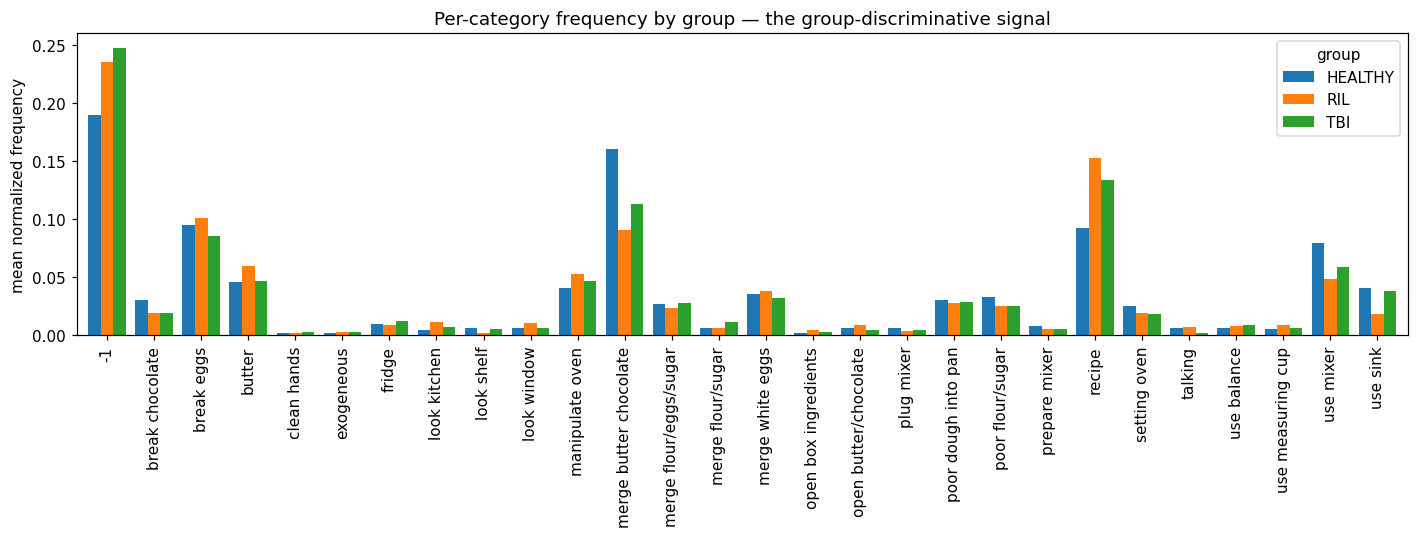

In [9]:
# --- FIGURE: per-category frequency by group (the discriminative signal) ---
G28 = D_G_cat.shape[0]
freq = np.vstack([np.bincount(x, minlength=G28) / len(x) for x in X_cat])
fdf = pd.DataFrame(freq, columns=code_to_label); fdf['group'] = labels
gmean = fdf.groupby('group').mean().T
fig, ax = plt.subplots(figsize=(13, 5))
gmean.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('mean normalized frequency'); ax.set_xlabel('')
ax.set_title('Per-category frequency by group — the group-discriminative signal')
plt.xticks(rotation=90); plt.tight_layout()
plt.savefig(os.path.join(OUT, 'g28_category_frequency_by_group.png'), dpi=130); plt.show()


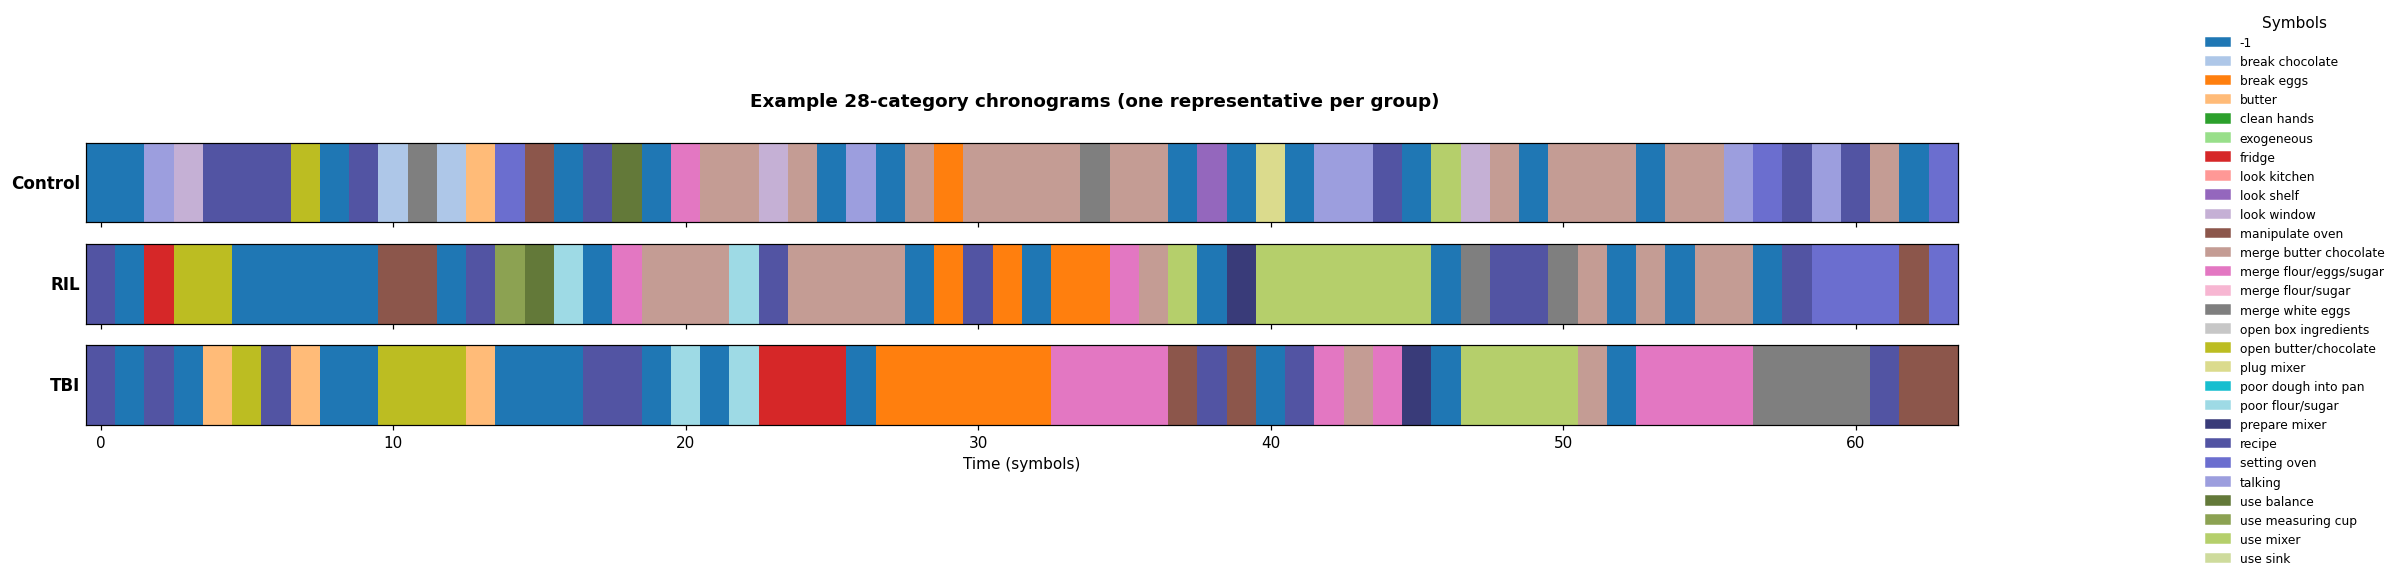

In [10]:
# --- FIGURE: example 28-category chronograms (one representative per group) ---
# Dedicated cohort renderer: ONE shared categorical colormap across cohorts + a
# named-category legend (replaces the ad-hoc per-axis tab20b imshow).
disp = {'HEALTHY': 'Control', 'RIL': 'RIL', 'TBI': 'TBI'}
examples = {disp[grp]: X_cat[np.where(labels == grp)[0][0]] for grp in ['HEALTHY', 'RIL', 'TBI']}
c2l = {i: code_to_label[i] for i in range(len(code_to_label)) if code_to_label[i] is not None}
plot_cohort_barycenters(
    examples, groups=['Control', 'RIL', 'TBI'],
    all_labels=np.arange(D_G_cat.shape[0]), code_to_label=c2l,
    title='Example 28-category chronograms (one representative per group)',
    savepath=os.path.join(OUT, 'g28_chronograms.png'),
)
plt.show()


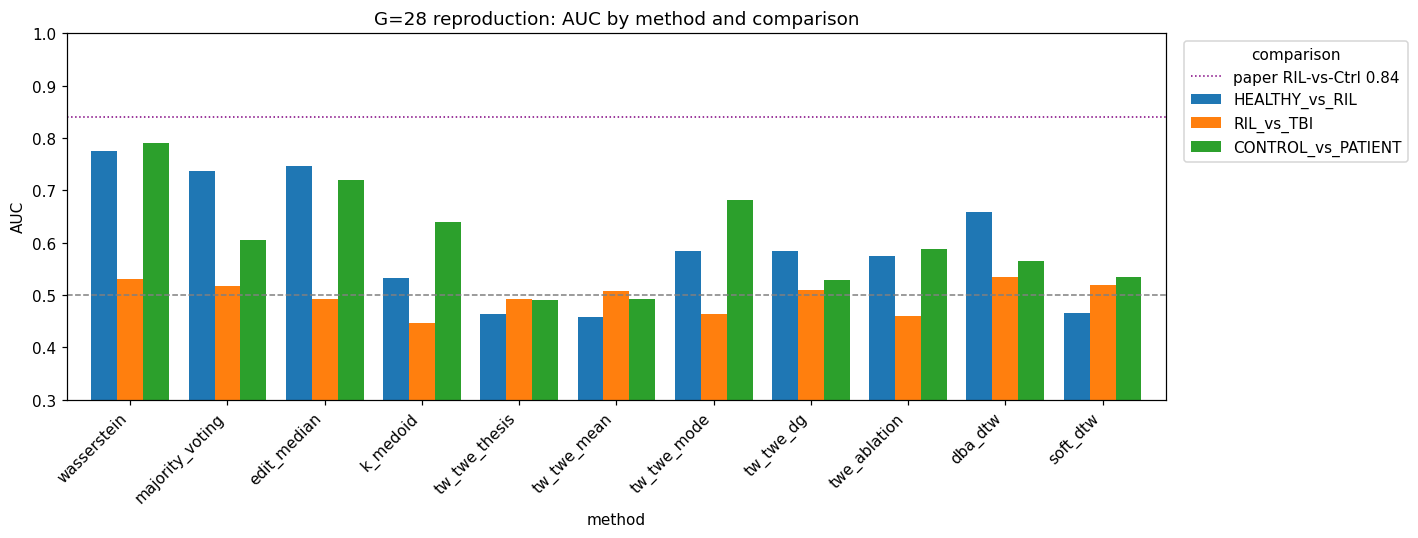

In [11]:
# --- FIGURE: AUC bar chart (method x comparison) ---
piv = df_all.groupby(['method', 'comparison'])['auc'].mean().unstack()
piv = piv.reindex([m for m in order if m in piv.index])
fig, ax = plt.subplots(figsize=(13, 5))
piv[[c for c in THREE if c in piv.columns]].plot(kind='bar', ax=ax, width=0.8)
ax.axhline(0.84, ls=':', c='purple', lw=1, label='paper RIL-vs-Ctrl 0.84')
ax.axhline(0.5, ls='--', c='gray', lw=1)
ax.set_ylabel('AUC'); ax.set_ylim(0.3, 1.0); ax.set_title('G=28 reproduction: AUC by method and comparison')
ax.legend(title='comparison', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig(os.path.join(OUT, 'g28_auc_bars.png'), dpi=130); plt.show()


## Findings (G=28 reproduction; cohort HEALTHY 24 / RIL 37 / TBI 59)

Observed AUC (10 splits x 3 inits). Paper targets: 0.84 / 0.59 / 0.77.

| method | RIL-vs-Ctrl | TBI-vs-RIL | Patient-vs-Ctrl |
|---|---|---|---|
| **histogram (wasserstein)** | **0.77** | 0.53 | **0.79** |
| majority voting | 0.74 | 0.52 | 0.61 |
| edit-distance median | 0.75 | 0.49 | 0.72 |
| TW-TWE + DBA (faithful mean, `tw_twe_thesis`) | 0.46 | 0.49 | 0.49 |
| TW-TWE + DBA (mode) | 0.58 | 0.46 | 0.68 |
| TW-TWE + DBA (D_G-Frechet) | 0.58 | 0.51 | 0.53 |

- The **symbol-frequency histogram reproduces Patient-vs-Control (0.79 ≈ paper 0.77)** and reaches 0.77 on
  RIL-vs-Control. The paper's headline **0.84** (RIL-vs-Control) is matched by the *finer G=77* histogram
  (06b / `RESULTS_HANDOFF_barycenters.md`), **not** G=28 — coarsening to 28 categories slightly *reduces* it.
- The **faithful TW-TWE+DBA barycenter is near-chance (0.46)**: averaging nominal category indices is
  categorically broken (see 06d Audit E — this holds whether or not D_G enters the averaging). The
  mode-based barycenter recovers some signal (0.58 / 0.68) but stays **below the frequency baselines**.
- **Honest verdict**: at G=28, as at G=77, the group-discriminative signal is *which categories occur*
  (frequency), captured directly by the histogram; temporal alignment does not improve on it. The mechanism
  and attempts to beat majority voting are in **06d**.